# Checking students work for AI-generated solutions.

Final Score = w1 * StyleScore 
            + w2 * ComplexityScore
            + w3 * LLMScore
            + w4 * SimilarityScore
            + w5 * SemanticScore

## Style analysis 

In [2]:
import ast
import re

def extract_style_features(code: str, language: str = ".py"):

    if language == ".py":
        return _extract_python_features(code)
    
    elif language in [".cpp", ".cs", ".pas", ".c"]:
        return _extract_cpp_features(code)
    
    else:
        raise ValueError(f"Unsupported language: {language}")
    
def _extract_python_features(code: str):
    try:
        tree = ast.parse(code)
    except:
        return _fallback_features(code)

    var_names = []

    for node in ast.walk(tree):
        if isinstance(node, ast.Name):
            var_names.append(node.id)

    avg_len = sum(len(v) for v in var_names) / (len(var_names) + 1)

    comment_count = len(re.findall(r'#.*', code))
    lines = len(code.split('\n'))
    comment_density = comment_count / (lines + 1)

    return {
        "avg_var_length": avg_len,
        "comment_density": comment_density,
        "num_variables": len(var_names)
    }

def _fallback_features(code: str):
    words = re.findall(r'\b[a-zA-Z_]{2,}\b', code)

    avg_len = sum(len(w) for w in words) / (len(words) + 1)

    comment_count = len(re.findall(r'#|//', code))
    lines = len(code.split('\n'))

    return {
        "avg_var_length": avg_len,
        "comment_density": comment_count / (lines + 1),
        "num_variables": len(words)
    }

def _extract_cpp_features(code: str):
    # Remove strings (to avoid false positives)
    code_clean = re.sub(r'"(\\.|[^"])*"', '', code)

    # Variable detection (simple heuristic)
    var_pattern = r'\b(int|float|double|char|bool|long|auto|string)\s+([a-zA-Z_][a-zA-Z0-9_]*)'
    matches = re.findall(var_pattern, code_clean)

    var_names = [m[1] for m in matches]

    avg_len = sum(len(v) for v in var_names) / (len(var_names) + 1)

    # Comments: // and /* */
    single_comments = re.findall(r'//.*', code)
    multi_comments = re.findall(r'/\*[\s\S]*?\*/', code)

    comment_count = len(single_comments) + len(multi_comments)

    lines = len(code.split('\n'))
    comment_density = comment_count / (lines + 1)

    return {
        "avg_var_length": avg_len,
        "comment_density": comment_density,
        "num_variables": len(var_names)
    }

## Spacing

Ai has very consistent identation, perfect spacing with low variance.

In [3]:
def indentation_consistency(code: str, features: dict):
    indents = []

    for line in code.split('\n'):
        spaces = len(line) - len(line.lstrip(' '))
        if spaces > 0:
            indents.append(spaces)

    if not indents:
        features["indentation_consistency"] = 0.5
        return features

    variance = sum((x - sum(indents)/len(indents))**2 for x in indents) / len(indents)

    features["indentation_consistency"] = 1 / (1 + variance)  # higher = more consistent
    return features 

## Repetition

Ai often repeats patterns, same structure etc.

In [4]:
def repetition_score(code: str, features: dict):
    lines = [l.strip() for l in code.split('\n') if l.strip()]
    unique = set(lines)

    features["repetition_score"] = 1 - len(unique) / (len(lines) + 1)
    return features

## Overexplanation in comments

In [5]:
import re

def overexplanation_in_comments(code: str, extension: str, features: dict):
    if extension == ".py":
        comments = re.findall(r'#.*', code)
    else:
        comments = re.findall(r'//.*|/\*[\s\S]*?\*/', code)

    overexplained = sum(len(c.split()) for c in comments) / len(comments) if comments else 0
    features["overexplanation_score"] = overexplained 
    return features

## All together

In [6]:
def analyze_code_style(code: str, language: str = ".py"):
    features = extract_style_features(code, language)
    features = indentation_consistency(code, features)
    features = repetition_score(code, features)
    features = overexplanation_in_comments(code, language, features)
    return features

## Go over all files and check

Error reading 2026-05-02 07-20-24.877700, tun_20_06, task_2026_14, Scored (6.0 - 100.0), task_2026_14.py: 'charmap' codec can't decode byte 0x8f in position 418: character maps to <undefined>
Error reading 2026-05-02 07-24-03.965795, tun_20_06, task_2026_14, Scored (6.0 - 100.0), task_2026_14.py: 'charmap' codec can't decode byte 0x8f in position 547: character maps to <undefined>
Error reading 2026-05-02 07-29-26.418949, tun_20_06, task_2026_12, Scored (52.0 - 100.0), task_2026_12.py: 'charmap' codec can't decode byte 0x81 in position 105: character maps to <undefined>
Error reading 2026-05-02 07-30-52.212384, tun_20_06, task_2026_12, Scored (52.0 - 100.0), task_2026_12.py: 'charmap' codec can't decode byte 0x81 in position 105: character maps to <undefined>
Error reading 2026-05-02 07-31-15.584430, tun_20_06, task_2026_14, Scored (6.0 - 100.0), task_2026_14.py: 'charmap' codec can't decode byte 0x8f in position 547: character maps to <undefined>
Error reading 2026-05-02 07-31-19.5811

<unknown>:3: SyntaxWarning: invalid decimal literal
C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_31192\407967511.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


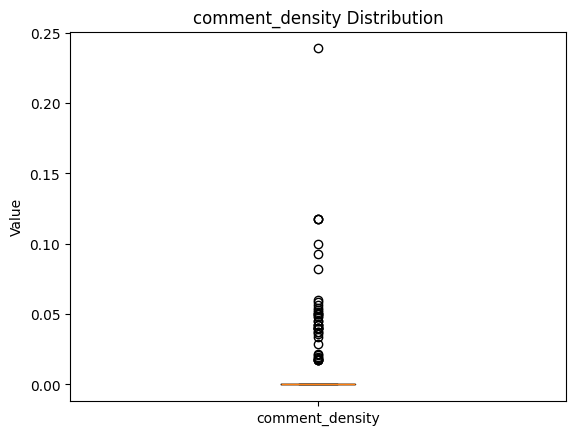

C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_31192\407967511.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


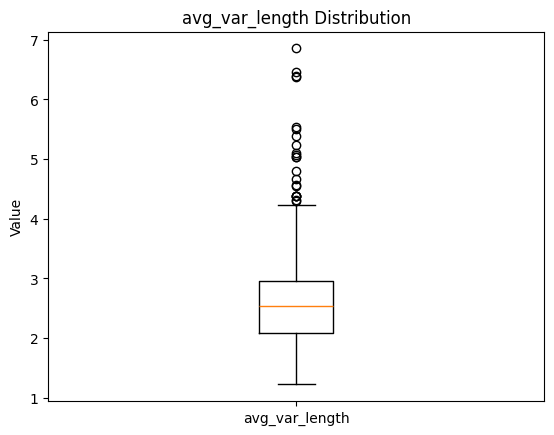

C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_31192\407967511.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


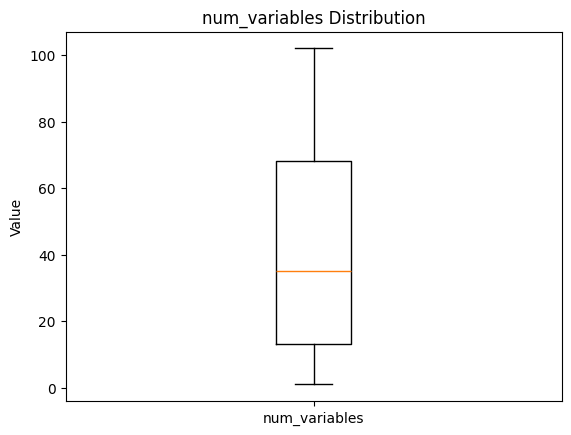

C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_31192\407967511.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


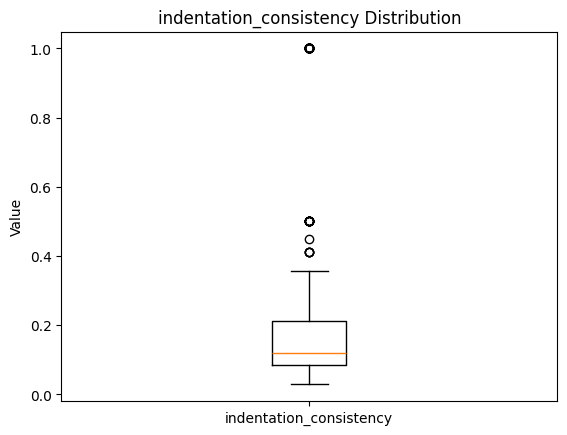

C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_31192\407967511.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


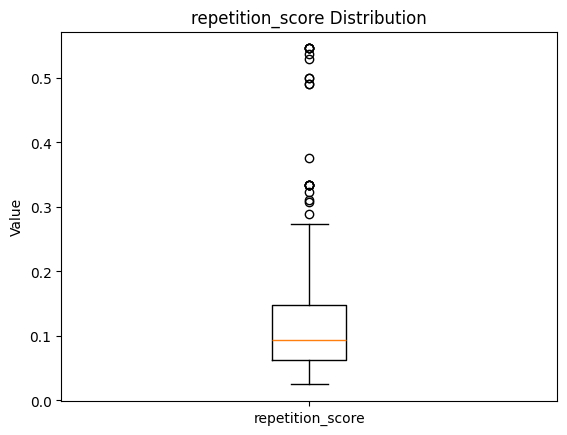

C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_31192\407967511.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


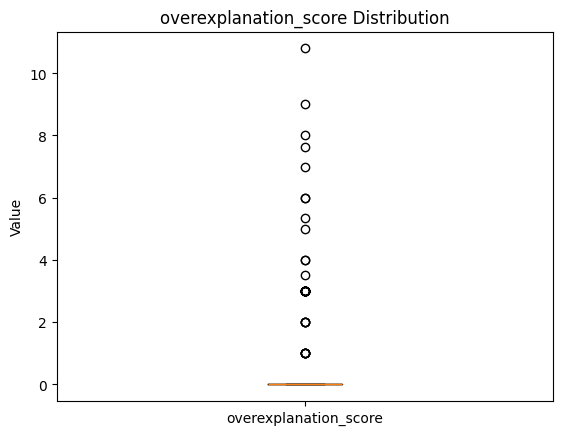

Outliers in comment_density:
2026-05-02 07-14-11.715144, sl16, task_2026_12, Scored (52.0 - 100.0), task_2026_12.cpp (nickname: sl16) - comment_density: 0.06
2026-05-02 07-17-06.141948, NotNiure, task_2026_11, Scored (0.0 - 100.0), task_2026_11.py (nickname: NotNiure) - comment_density: 0.11764705882352941
2026-05-02 07-18-18.899900, NotNiure, task_2026_15, Scored (60.0 - 100.0), task_2026_15.py (nickname: NotNiure) - comment_density: 0.11764705882352941
2026-05-02 07-23-38.826129, NotNiure, task_2026_15, Scored (100.0 - 100.0), task_2026_15.py (nickname: NotNiure) - comment_density: 0.1
2026-05-02 07-37-03.089403, sl16, task_2026_15, Scored (100.0 - 100.0), task_2026_15.cpp (nickname: sl16) - comment_density: 0.04477611940298507
2026-05-02 07-40-27.150259, NotNiure, task_2026_13, Scored (60.0 - 100.0), task_2026_13.py (nickname: NotNiure) - comment_density: 0.05
2026-05-02 07-42-04.405770, NotNiure, task_2026_13, Scored (60.0 - 100.0), task_2026_13.py (nickname: NotNiure) - comment_de

In [17]:
import os

folder_path = os.path.join(os.getcwd(), "submissions")

student_nicknames = set()
filenames = os.listdir(folder_path)

for filename in filenames:
    nickname = filename.split(",")[1].strip()
    student_nicknames.add(nickname)

# print("Unique student nicknames:")
# for nickname in student_nicknames:
#     print(nickname)

feture_list = []

for file_name in filenames:
    nickname = file_name.split(",")[1].strip()
    
    try:
        file_content = open(os.path.join(folder_path, file_name)).read()
    except Exception as e:
        print(f"Error reading {file_name}: {e}")
        continue

    extension = os.path.splitext(file_name)[1]
    features = analyze_code_style(file_content, language=extension)

    features["nickname"] = nickname
    features["file_name"] = file_name
    feture_list.append(features)

import numpy as np
import matplotlib.pyplot as plt

def display_box_plot(feature_name):
    data = [f[feature_name] for f in feture_list]
    plt.boxplot(data, labels=[feature_name])
    plt.title(f'{feature_name} Distribution')
    plt.ylabel('Value')
    plt.show()

display_box_plot("comment_density")
display_box_plot("avg_var_length")
display_box_plot("num_variables")
display_box_plot("indentation_consistency")
display_box_plot("repetition_score")
display_box_plot("overexplanation_score")

def detect_outliers(feature_name):
    data = np.array([f[feature_name] for f in feture_list])
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = [f for f in feture_list if f[feature_name] < lower_bound or f[feature_name] > upper_bound]
    return outliers

print("Outliers in comment_density:")
outliers_comment_density = detect_outliers("comment_density")
for o in outliers_comment_density:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - comment_density: {o['comment_density']}")

print("\nOutliers in avg_var_length:")
outliers_avg_var_length = detect_outliers("avg_var_length")
for o in outliers_avg_var_length:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - avg_var_length: {o['avg_var_length']}")

print("\nOutliers in num_variables:")
outliers_num_variables = detect_outliers("num_variables")
for o in outliers_num_variables:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - num_variables: {o['num_variables']}")
# print(feture_list)

print("\nOutliers in indentation_consistency:")
outliers_indentation_consistency = detect_outliers("indentation_consistency")
for o in outliers_indentation_consistency:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - indentation_consistency: {o['indentation_consistency']}")

print("\nOutliers in repetition_score:")
outliers_repetition_score = detect_outliers("repetition_score")
for o in outliers_repetition_score:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - repetition_score: {o['repetition_score']}")

print("\nOutliers in repetition_score:")
outliers_repetition_score = detect_outliers("repetition_score")
for o in outliers_repetition_score:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - repetition_score: {o['repetition_score']}")

print("\nOutliers in overexplanation_score:")
outliers_overexplanation_score = detect_outliers("overexplanation_score")
for o in outliers_overexplanation_score:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - overexplanation_score: {o['overexplanation_score']}")

# outliers = set([o["file_name"] for o in outliers_comment_density]).intersection(set([o["file_name"] for o in outliers_avg_var_length])) #+ set(outliers_num_variables)
# print("\nStudents with outliers in both comment_density and avg_var_length:")
# print(outliers)

outliers_json = {
    "comment_density": [o["file_name"] for o in outliers_comment_density],
    "avg_var_length": [o["file_name"] for o in outliers_avg_var_length],
    "num_variables": [o["file_name"] for o in outliers_num_variables],
    "indentation_consistency": [o["file_name"] for o in outliers_indentation_consistency],
    "repetition_score": [o["file_name"] for o in outliers_repetition_score],
    "overexplanation_score": [o["file_name"] for o in outliers_overexplanation_score]
}

import json
with open("outliers.json", "w") as f:
    json.dump(outliers_json, f, indent=4)

In [ ]:
import json
import pandas as pd
from pathlib import Path

datasets_dir = Path.cwd() / 'datasets'
third = pd.read_csv(datasets_dir / 'third.csv')
solutions = pd.read_csv(datasets_dir / 'solutions.csv')

df = third.merge(solutions[['SolutionID','Language']], on='SolutionID', how='left')

# Filter out rows where Language is NaN
df_clean = df.dropna(subset=['Language'])

print(f"Rows with Language values: {len(df_clean)} (dropped {len(df) - len(df_clean)})")

def lang_to_ext(lang):
    """Map language string to file extension."""
    if pd.isna(lang):
        return '.txt'
    l = str(lang).upper()
    token = l.split()[0]  # Take first token before space/version
    if 'PYTH' in token:
        return '.py'
    if 'C++' in token or 'CPP' in token:
        return '.cpp'
    if 'JAVA' in token:
        return '.java'
    if 'C#' in token or 'CS' in token:
        return '.cs'
    if 'PAS' in token:
        return '.pas'
    if token == 'C':
        return '.c'
    return '.txt'

# Run analyze_code_style on clean data
results = []
errors = []

for idx, row in df_clean.iterrows():
    sol_id = row.get('SolutionID')
    code = str(row.get('Solutions', ''))
    lang = row.get('Language', '')
    ext = lang_to_ext(lang)
    
    try:
        features = analyze_code_style(code, language=ext)
        features['SolutionID'] = sol_id
        features['Language'] = lang
        features['FileExtension'] = ext
        results.append(features)
    except Exception as e:
        errors.append({
            'SolutionID': sol_id,
            'Language': lang,
            'Error': str(e)
        })

print(f"\nSuccessfully analyzed: {len(results)} solutions")
if errors:
    print(f"Errors encountered: {len(errors)}")

# Save results to JSON
with open('style_analysis_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("\nResults saved to style_analysis_results.json")

# Display sample results
if results:
    print(f"\nSample result (first solution):")
    print(json.dumps(results[0], indent=2))

Rows with Language values: 167988 (dropped 143861)

Successfully analyzed: 138605 solutions
Errors encountered: 29383

Results saved to style_analysis_results.json

Sample result (first solution):
{
  "avg_var_length": 2.0,
  "comment_density": 0.0,
  "num_variables": 4,
  "indentation_consistency": 1.0,
  "repetition_score": 0.16000000000000003,
  "overexplanation_score": 0,
  "SolutionID": "S11966595",
  "Language": "C++14",
  "FileExtension": ".cpp"
}
